In [3]:
### TASK 1: DATA COLLECTION & DATASET UNDERSTANDING ###

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("Teen_Mental_Health.csv")

In [5]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,14,male,7.9,Facebook,7.4,2.9,3.01,1.5,low,2,2,1,0,5,Fair,At Risk
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,19,Good,Moderate
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,8,Fair,Healthy
3,15,male,7.4,YouTube,6.9,1.6,3.48,0.8,medium,1,7,9,0,17,Fair,Moderate
4,15,female,4.7,All Platforms,4.9,3.0,2.37,1.4,medium,3,5,2,0,10,Poor,Moderate


In [6]:
df.shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1200
Columns: 16


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
 13  mental_health_risk_score  1200 non-null   int64  
 14  sleep_qu

In [8]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label',
       'mental_health_risk_score', 'sleep_quality', 'digital_wellbeing_flag'],
      dtype='object')

In [9]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833,16.647500
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704,5.038128
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000,13.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000,17.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000,20.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000,30.000000


In [10]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


This dataset contains information related to teen mental health,
sleep habits, social media usage, academic performance, and
behavioral patterns. the columns represent demographic, behavioral, and mental health-related features. while the rows represent 1 student observation.

number of rows: 1200
number of columns: 16
dataset has zero missing values and ut includes both numerical and categorial data types.

In [11]:
##### TASK 4: DATA VISUALIZATION #####

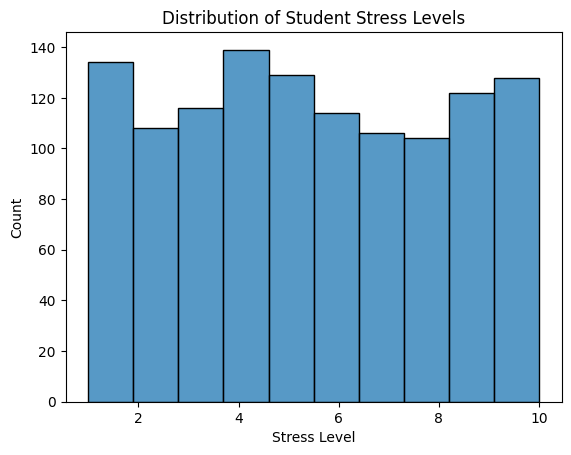

In [12]:
#visualization 1
sns.histplot(df["stress_level"], bins=10)
plt.title("Distribution of Student Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()

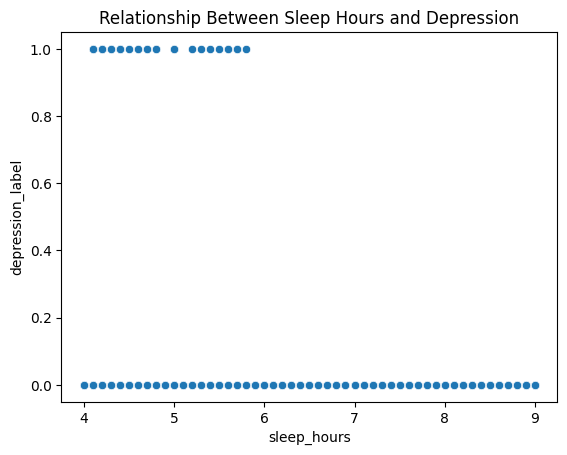

In [13]:
#visualization 2
sns.scatterplot(x="sleep_hours", y="depression_label", data=df)
plt.title("Relationship Between Sleep Hours and Depression")
plt.show()

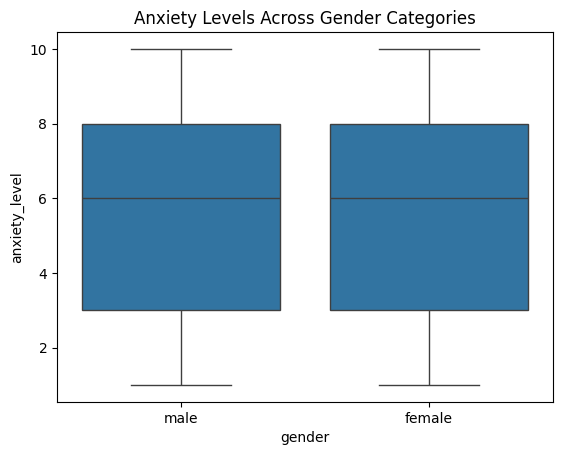

In [14]:
#visualization 3
sns.boxplot(x="gender", y="anxiety_level", data=df)
plt.title("Anxiety Levels Across Gender Categories")
plt.show()

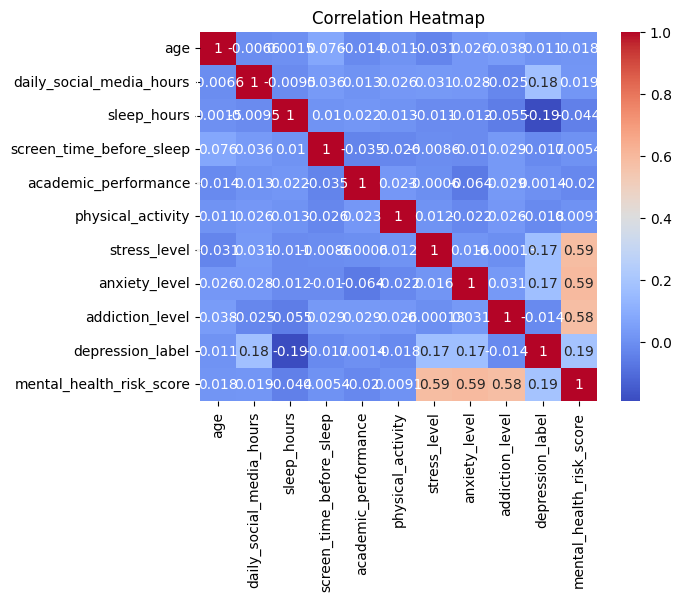

In [15]:
#visualization 4
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
##### TASK 5: Predictive Model or Insight Project #####

In [17]:
le = LabelEncoder()

categorical_cols = [
    "gender",
    "platform_usage",
    "social_interaction_level",
    "sleep_quality",
    "digital_wellbeing_flag"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
X = df.drop("depression_label", axis=1)

Y = df["depression_label"]

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2,random_state=42, stratify=Y
)

In [20]:
model = RandomForestClassifier(random_state=42, class_weight="balanced")

model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [21]:
predictions = model.predict(X_test)

In [22]:
accuracy = accuracy_score(Y_test, predictions)

print("Accuracy:", accuracy)
print(classification_report(Y_test, predictions))

Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240



A Random Forest classification model was developed
to predict depression labels using behavioral and
mental health-related features.

Categorical variables were encoded using Label Encoding,
and class balancing was applied due to dataset imbalance.
